File 'Placement_Data_Full_Class.csv' not found. Please upload it.


Saving archive.zip to archive (1).zip
User uploaded file "archive (1).zip" with length 4615 bytes
First 5 rows:
    sl_no gender  ssc_p    ssc_b  hsc_p    hsc_b     hsc_s  degree_p  \
0      1      M  67.00   Others  91.00   Others  Commerce     58.00   
1      2      M  79.33  Central  78.33   Others   Science     77.48   
2      3      M  65.00  Central  68.00  Central      Arts     64.00   
3      4      M  56.00  Central  52.00  Central   Science     52.00   
4      5      M  85.80  Central  73.60  Central  Commerce     73.30   

    degree_t workex  etest_p specialisation  mba_p      status    salary  
0   Sci&Tech     No     55.0         Mkt&HR  58.80      Placed  270000.0  
1   Sci&Tech    Yes     86.5        Mkt&Fin  66.28      Placed  200000.0  
2  Comm&Mgmt     No     75.0        Mkt&Fin  57.80      Placed  250000.0  
3   Sci&Tech     No     66.0         Mkt&HR  59.43  Not Placed       NaN  
4  Comm&Mgmt     No     96.8        Mkt&Fin  55.50      Placed  425000.0  

--- MODEL

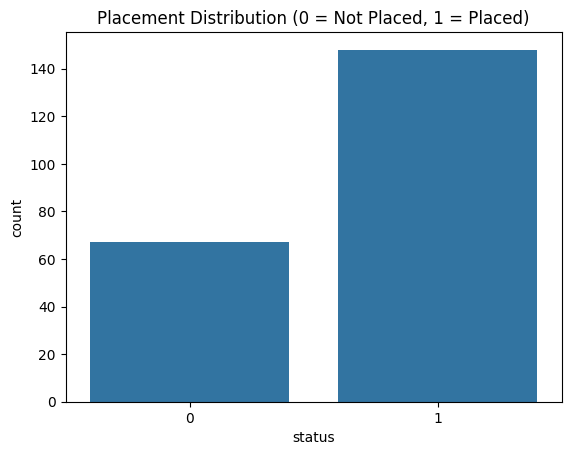

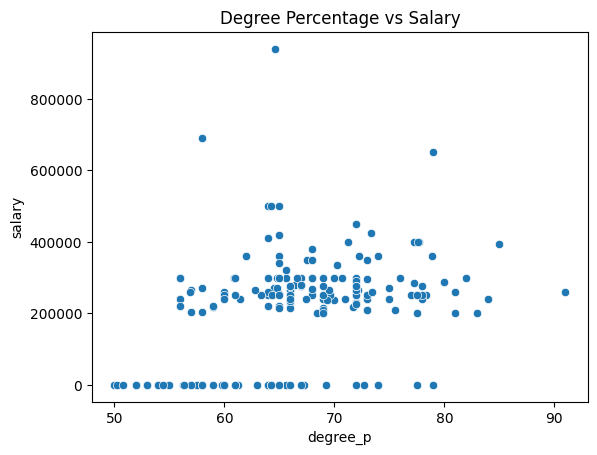

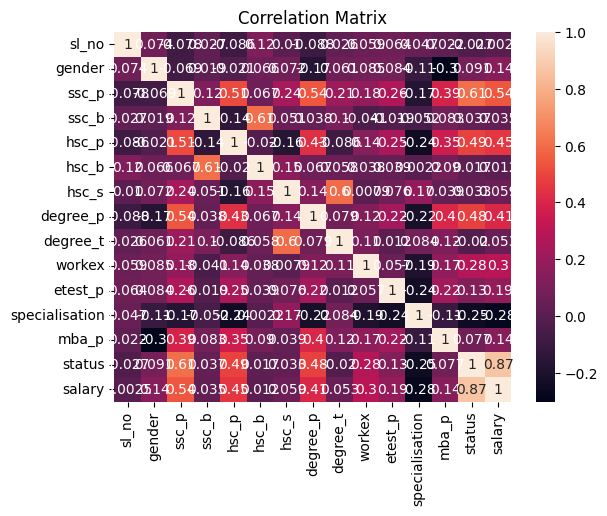

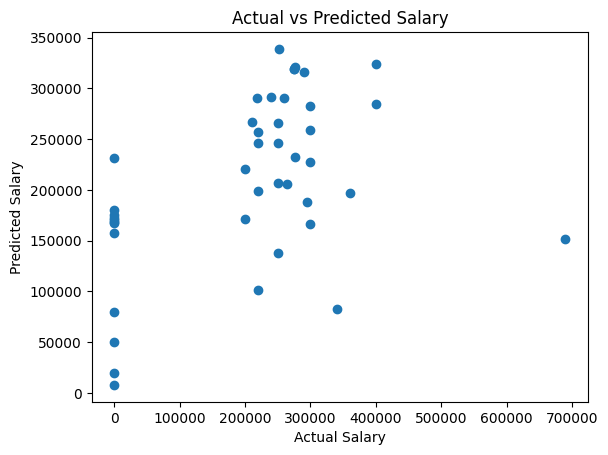


--- NEW STUDENT RESULT ---
Placement: Placed
Predicted Salary: 298874.27 LPA


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# -----------------------------
# IMPORT LIBRARIES
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files # Import files module for uploading

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix

# -----------------------------
# LOAD DATASET (CSV FILE)
# -----------------------------
# Check if the file exists locally, otherwise prompt for upload
try:
    df = pd.read_csv("Placement_Data_Full_Class.csv")
except FileNotFoundError:
    print("File 'Placement_Data_Full_Class.csv' not found. Please upload it.")
    uploaded = files.upload()
    for fn in uploaded.keys():
        print('User uploaded file "{name}" with length {length} bytes'.format(
            name=fn, length=len(uploaded[fn])))
    # Assuming the user uploads the correct file name, now use the uploaded filename
    df = pd.read_csv(fn)

print("First 5 rows:\n", df.head())

# -----------------------------
# DATA PREPROCESSING
# -----------------------------

# Fill missing salary (for not placed students)
df['salary'] = df['salary'].fillna(0)

# Convert categorical columns to numeric
le = LabelEncoder()

categorical_cols = ['gender', 'ssc_b', 'hsc_b', 'hsc_s',
                    'degree_t', 'workex', 'specialisation', 'status']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# -----------------------------
# FEATURE SELECTION
# -----------------------------
features = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']

X = df[features]

# Targets
y_class = df['status']   # Placement (0/1)
y_reg = df['salary']     # Salary

# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_class_train, y_class_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

_, _, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# -----------------------------
# MODEL TRAINING
# -----------------------------

# Classification Model
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_class_train)

# Regression Model
reg = LinearRegression()
reg.fit(X_train, y_reg_train)

# -----------------------------
# PREDICTIONS
# -----------------------------
y_pred_class = clf.predict(X_test)
y_pred_reg = reg.predict(X_test)

# -----------------------------
# EVALUATION
# -----------------------------
print("\n--- MODEL PERFORMANCE ---")

print("Classification Accuracy:",
      accuracy_score(y_class_test, y_pred_class))

print("Regression MSE:",
      mean_squared_error(y_reg_test, y_pred_reg))

# Confusion Matrix
cm = confusion_matrix(y_class_test, y_pred_class)
print("\nConfusion Matrix:\n", cm)

# -----------------------------
# GRAPHS
# -----------------------------

# 1. Placement Distribution
plt.figure()
sns.countplot(x=df['status'])
plt.title("Placement Distribution (0 = Not Placed, 1 = Placed)")
plt.show()

# 2. CGPA vs Salary
plt.figure()
sns.scatterplot(x=df['degree_p'], y=df['salary'])
plt.title("Degree Percentage vs Salary")
plt.show()

# 3. Correlation Heatmap
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

# 4. Actual vs Predicted Salary
plt.figure()
plt.scatter(y_reg_test, y_pred_reg)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

# -----------------------------
# TEST WITH NEW INPUT
# -----------------------------
# Example: ssc_p=85, hsc_p=80, degree_p=75, etest_p=70, mba_p=80
new_student = np.array([[85, 80, 75, 70, 80]])

placement = clf.predict(new_student)
salary = reg.predict(new_student)

print("\n--- NEW STUDENT RESULT ---")
print("Placement:",
      "Placed" if placement[0] == 1 else "Not Placed")

print("Predicted Salary:",
      round(salary[0], 2), "LPA")
